# Requirement Setup

In [3]:
!pip install scikit-learn
!pip install tensorflow
!pip install setuptools

In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import time
import matplotlib.pyplot as plt
from datetime import datetime
import os

In [5]:
np.random.seed(42)
tf.random.set_seed(42)

# Data Loading

In [6]:
raw_df = pd.read_csv('../data/data.csv', parse_dates=['timestamp'])
primary_service = raw_df['service_id'].mode()[0]
df_pods = raw_df[raw_df['service_id'] == primary_service].copy()
df_pods = df_pods.sort_values('timestamp').drop_duplicates(subset='timestamp')
df_pods.rename(columns={'timestamp': 'ds', 'current_pod_count': 'pod_count'}, inplace=True)
feature_cols = [c for c in df_pods.columns if c not in ['ds', 'service_id', 'pod_count']]

print(f'Using service: {primary_service}')
print(f'Dataset length: {len(df_pods)} | Feature count: {len(feature_cols)}')
print(f'Features: {feature_cols}')
df_pods[['ds', 'pod_count']].head()

Using service: Order
Dataset length: 43200 | Feature count: 20
Features: ['request_rate_rps', 'latency_p95_ms', 'latency_p99_ms', 'error_rate_percent', 'queue_length', 'pod_cpu_usage_percent_avg', 'pod_cpu_usage_percent_p95', 'pod_memory_usage_mb_avg', 'pod_memory_usage_mb_p95', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'mesh_inbound_rps', 'mesh_inbound_latency_p95', 'mesh_inbound_error_rate', 'degree_centrality', 'eigenvector_centrality', 'betweenness_centrality', 'closeness_centrality']


,ds,pod_count
0,2025-11-01 00:00:00,2
1,2025-11-01 00:01:00,2
2,2025-11-01 00:02:00,2
3,2025-11-01 00:03:00,2
4,2025-11-01 00:04:00,2


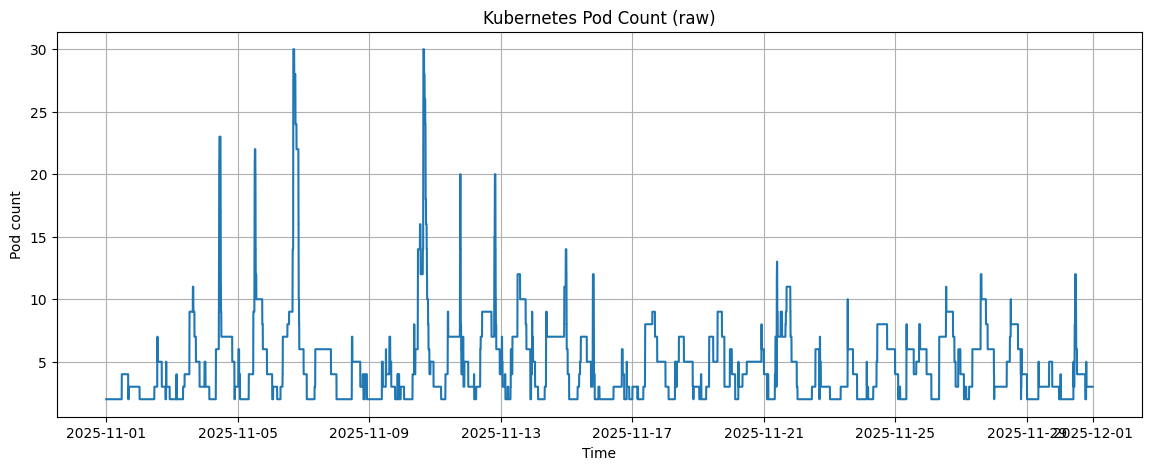

In [7]:
# Ensure images directory exists before saving plots
os.makedirs("images", exist_ok=True)

plt.figure(figsize=(14, 5))
plt.plot(df_pods['ds'], df_pods['pod_count'])
plt.title('Kubernetes Pod Count (raw)')
plt.xlabel('Time')
plt.ylabel('Pod count')
plt.grid(True)
plt.savefig("images/tcn-pods-raw.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

# Data Splitting & Preprocessing

1. Scale pod count and features to 0-1
2. Split dataset as 70% training, 30% testing (time-ordered)
3. Forward-fill missing values
4. Drop duplicate timestamps

In [8]:
target_scaler = MinMaxScaler(feature_range=(0, 1))
feature_scaler = MinMaxScaler()

df_pods['y'] = target_scaler.fit_transform(df_pods[['pod_count']])
df_pods[feature_cols] = feature_scaler.fit_transform(df_pods[feature_cols])

In [9]:
# Add time features
df_pods['hour'] = df_pods['ds'].dt.hour / 23.0
df_pods['dayofweek'] = df_pods['ds'].dt.dayofweek / 6.0
df_pods['dayofmonth'] = (df_pods['ds'].dt.day - 1) / 30.0
df_pods['month'] = (df_pods['ds'].dt.month - 1) / 11.0

time_features = ['hour', 'dayofweek', 'dayofmonth', 'month']
print(f'Added time features: {time_features}')

Added time features: ['hour', 'dayofweek', 'dayofmonth', 'month']


In [10]:
train_df_pods, test_df_pods = train_test_split(df_pods, test_size=0.3, random_state=42, shuffle=False)

print(f'POD DATASET: Train Set: {train_df_pods.shape} | Test Set: {test_df_pods.shape}')

POD DATASET: Train Set: (30240, 28) | Test Set: (12960, 28)


In [11]:
train_df_pods['y'].fillna(method='ffill', inplace=True)
train_df_pods.drop_duplicates(subset='ds', inplace=True)

print(f'POD DATASET: Train Set: {train_df_pods.shape} | Test Set: {test_df_pods.shape}')

POD DATASET: Train Set: (30240, 28) | Test Set: (12960, 28)


C:\Users\dilee\AppData\Local\Temp\ipykernel_31244\4286280144.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df_pods['y'].fillna(method='ffill', inplace=True)
C:\Users\dilee\AppData\Local\Temp\ipykernel_31244\4286280144.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df_pods['y'].fillna(method='ffill', inplace=True)


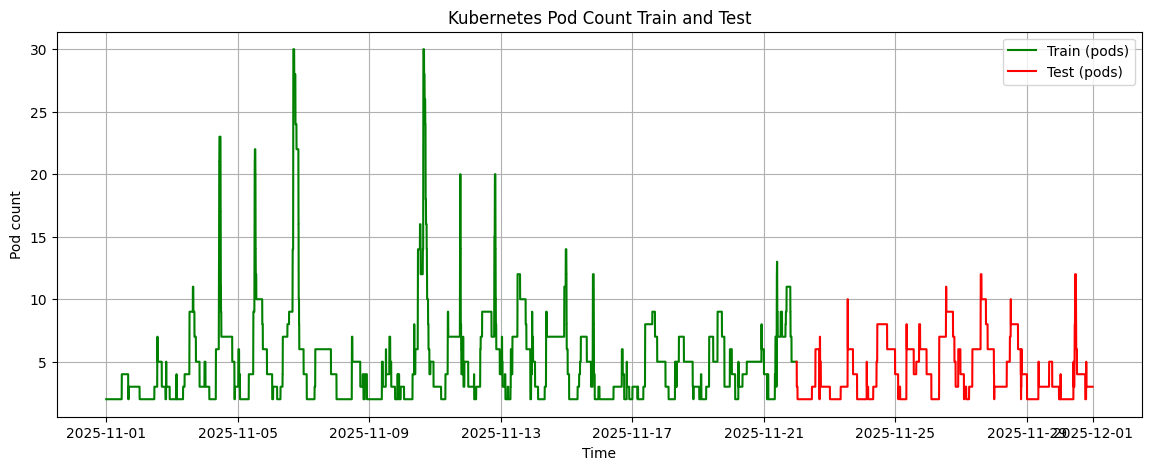

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(train_df_pods['ds'], train_df_pods['pod_count'], label='Train (pods)', color='green')
plt.plot(test_df_pods['ds'], test_df_pods['pod_count'], label='Test (pods)', color='red')
plt.title('Kubernetes Pod Count Train and Test')
plt.xlabel('Time')
plt.ylabel('Pod count')
plt.grid(True)
plt.legend()
plt.savefig("images/tcn-pods-train-test.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

# TCN Model Architecture

Key components:
1. **Dilated Causal Convolutions**: Ensures no information leakage from future
2. **Residual Blocks**: Skip connections for gradient flow
3. **Weight Normalization**: Stabilizes training
4. **Dropout**: Regularization

## TCN Building Blocks

In [13]:
class CausalConv1D(layers.Layer):
    """Causal Convolution layer that ensures no future information leakage."""
    
    def __init__(self, filters, kernel_size, dilation_rate=1, **kwargs):
        super(CausalConv1D, self).__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.dilation_rate = dilation_rate
        self.padding = (kernel_size - 1) * dilation_rate
        
    def build(self, input_shape):
        self.conv = layers.Conv1D(
            filters=self.filters,
            kernel_size=self.kernel_size,
            dilation_rate=self.dilation_rate,
            padding='causal',
            kernel_initializer='he_normal'
        )
        super(CausalConv1D, self).build(input_shape)
        
    def call(self, x):
        return self.conv(x)
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'filters': self.filters,
            'kernel_size': self.kernel_size,
            'dilation_rate': self.dilation_rate
        })
        return config

In [14]:
class TemporalBlock(layers.Layer):
    """Temporal Block with two causal convolutions, residual connection, and dropout."""
    
    def __init__(self, filters, kernel_size, dilation_rate, dropout_rate=0.2, **kwargs):
        super(TemporalBlock, self).__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.dilation_rate = dilation_rate
        self.dropout_rate = dropout_rate
        
    def build(self, input_shape):
        # First causal convolution
        self.conv1 = CausalConv1D(
            filters=self.filters,
            kernel_size=self.kernel_size,
            dilation_rate=self.dilation_rate
        )
        self.norm1 = layers.BatchNormalization()
        self.dropout1 = layers.Dropout(self.dropout_rate)
        
        # Second causal convolution
        self.conv2 = CausalConv1D(
            filters=self.filters,
            kernel_size=self.kernel_size,
            dilation_rate=self.dilation_rate
        )
        self.norm2 = layers.BatchNormalization()
        self.dropout2 = layers.Dropout(self.dropout_rate)
        
        # Residual connection (1x1 conv if dimensions don't match)
        self.downsample = None
        if input_shape[-1] != self.filters:
            self.downsample = layers.Conv1D(self.filters, 1, kernel_initializer='he_normal')
            
        super(TemporalBlock, self).build(input_shape)
        
    def call(self, x, training=None):
        # First convolution block
        out = self.conv1(x)
        out = self.norm1(out, training=training)
        out = tf.nn.relu(out)
        out = self.dropout1(out, training=training)
        
        # Second convolution block
        out = self.conv2(out)
        out = self.norm2(out, training=training)
        out = tf.nn.relu(out)
        out = self.dropout2(out, training=training)
        
        # Residual connection
        res = x if self.downsample is None else self.downsample(x)
        
        return tf.nn.relu(out + res)
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'filters': self.filters,
            'kernel_size': self.kernel_size,
            'dilation_rate': self.dilation_rate,
            'dropout_rate': self.dropout_rate
        })
        return config

In [15]:
class TCN(layers.Layer):
    """Temporal Convolutional Network.
    
    Stacks multiple TemporalBlocks with exponentially increasing dilation rates.
    """
    
    def __init__(self, num_channels, kernel_size=3, dropout_rate=0.2, **kwargs):
        super(TCN, self).__init__(**kwargs)
        self.num_channels = num_channels  # List of channel sizes for each layer
        self.kernel_size = kernel_size
        self.dropout_rate = dropout_rate
        
    def build(self, input_shape):
        self.temporal_blocks = []
        num_levels = len(self.num_channels)
        
        for i in range(num_levels):
            dilation_rate = 2 ** i  # Exponentially increasing dilation
            block = TemporalBlock(
                filters=self.num_channels[i],
                kernel_size=self.kernel_size,
                dilation_rate=dilation_rate,
                dropout_rate=self.dropout_rate
            )
            self.temporal_blocks.append(block)
            
        super(TCN, self).build(input_shape)
        
    def call(self, x, training=None):
        for block in self.temporal_blocks:
            x = block(x, training=training)
        return x
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'num_channels': self.num_channels,
            'kernel_size': self.kernel_size,
            'dropout_rate': self.dropout_rate
        })
        return config

## Build TCN Model

In [16]:
def build_tcn_model(
    input_shape,
    num_channels=[64, 64, 64, 64],
    kernel_size=3,
    dropout_rate=0.2,
    output_size=1
):
    """Build TCN model for time-series forecasting.
    
    Args:
        input_shape: Tuple of (sequence_length, num_features)
        num_channels: List of channel sizes for each TCN layer
        kernel_size: Convolution kernel size
        dropout_rate: Dropout rate
        output_size: Number of output features (1 for single-step prediction)
        
    Returns:
        Keras Model
    """
    # Calculate receptive field
    receptive_field = 1 + 2 * (kernel_size - 1) * (2 ** len(num_channels) - 1)
    print(f'Receptive field: {receptive_field} time steps')
    
    # Input
    inputs = layers.Input(shape=input_shape)
    
    # TCN layers
    x = TCN(
        num_channels=num_channels,
        kernel_size=kernel_size,
        dropout_rate=dropout_rate
    )(inputs)
    
    # Take the last time step output
    x = layers.Lambda(lambda t: t[:, -1, :])(x)
    
    # Dense layers for prediction
    x = layers.Dense(64, activation='relu', kernel_initializer='he_normal')(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(32, activation='relu', kernel_initializer='he_normal')(x)
    outputs = layers.Dense(output_size)(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    
    return model

# Model Training

## Prepare Dataset for TCN

In [17]:
def create_dataset(features, target, look_back, horizon=5):
    """Create sliding window sequences for time-series prediction at a future horizon.

    Args:
        features: DataFrame or array of input features
        target: Array of target values
        look_back: Number of time steps to look back
        horizon: Predict target at t + horizon (minutes ahead)
    Returns:
        X: 3D array of shape (samples, look_back, features)
        y: 1D array of target values at t + horizon
    """
    X, y = [], []
    features = np.array(features)
    target = np.array(target)
    max_idx = len(target) - look_back - horizon + 1
    for i in range(max_idx):
        X.append(features[i:i + look_back, :])
        y.append(target[i + look_back + horizon - 1])
    return np.array(X), np.array(y)

In [18]:
# Sliding window size (look_back) and forecast horizon
look_back = 48  # TCN can handle longer sequences efficiently
horizon = 5     # predict 5 minutes ahead

# Use all features + target + time features for multivariate input
input_feature_cols = feature_cols + time_features + ['y']

X_pods, y_pods = create_dataset(df_pods[input_feature_cols], df_pods['y'], look_back, horizon=horizon)

print(f'Input shape: {X_pods.shape}')
print(f'Target shape: {y_pods.shape}')
print(f'Features used: {len(input_feature_cols)}')
print(f'Look-back: {look_back} | Horizon (minutes): {horizon}')

Input shape: (43148, 48, 25)
Target shape: (43148,)
Features used: 25
Look-back: 48 | Horizon (minutes): 5


In [19]:
X_train_pods, X_test_pods, y_train_pods, y_test_pods = train_test_split(
    X_pods, y_pods, test_size=0.3, random_state=42, shuffle=False
)

num_features = X_train_pods.shape[2]

print(f'POD DATASET: Train Set: {X_train_pods.shape} | Test Set: {X_test_pods.shape}')
print(f'Number of features: {num_features}')

POD DATASET: Train Set: (30203, 48, 25) | Test Set: (12945, 48, 25)
Number of features: 25


## Model Configuration

In [20]:
# TCN hyperparameters
NUM_CHANNELS = [64, 64, 64, 64]  # 4 layers with 64 filters each
KERNEL_SIZE = 3                   # Convolution kernel size
DROPOUT_RATE = 0.2               # Dropout rate

print('TCN Configuration:')
print(f'  num_channels: {NUM_CHANNELS}')
print(f'  kernel_size: {KERNEL_SIZE}')
print(f'  dropout_rate: {DROPOUT_RATE}')
print(f'  num_layers: {len(NUM_CHANNELS)}')

TCN Configuration:
  num_channels: [64, 64, 64, 64]
  kernel_size: 3
  dropout_rate: 0.2
  num_layers: 4


In [21]:
# Compute receptive field (number of past steps the TCN can leverage)
receptive_field = 1 + 2 * (KERNEL_SIZE - 1) * (2 ** len(NUM_CHANNELS) - 1)
print(f'Receptive field (time steps): {receptive_field}')

Receptive field (time steps): 61


In [22]:
# Build model
model = build_tcn_model(
    input_shape=(look_back, num_features),
    num_channels=NUM_CHANNELS,
    kernel_size=KERNEL_SIZE,
    dropout_rate=DROPOUT_RATE,
    output_size=1
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

Receptive field: 61 time steps



In [23]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 25)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn (TCN)                       │ (None, 48, 64)         │        95,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,313 (395.75 KB)

 Trainable params: 100,289 (391.75 KB)

 Non-trainable params: 1,024 (4.00 KB)

## Callbacks

In [24]:
os.makedirs('models', exist_ok=True)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'models/tcn_k8s_best.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

## Train Model

In [25]:
history = model.fit(
    X_train_pods, y_train_pods,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 1.6059 - mae: 0.7595
Epoch 1: val_loss improved from None to 0.00843, saving model to models/tcn_k8s_best.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 23s 42ms/step - loss: 0.5040 - mae: 0.4085 - val_loss: 0.0084 - val_mae: 0.0739 - learning_rate: 0.0010
Epoch 2/100
377/378 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0364 - mae: 0.1405
Epoch 2: val_loss improved from 0.00843 to 0.00587, saving model to models/tcn_k8s_best.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - loss: 0.0286 - mae: 0.1221 - val_loss: 0.0059 - val_mae: 0.0584 - learning_rate: 0.0010
Epoch 3/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0153 - mae: 0.0878
Epoch 3: val_loss improved from 0.00587 to 0.00455, saving model to models/tcn_k8s_best.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - loss: 0.0133 - mae: 0.0814 - val_loss: 0.0045 - val_mae: 0.0520 - learning_rate: 0.0010
Epoch 4/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0102 - ma

### Training History

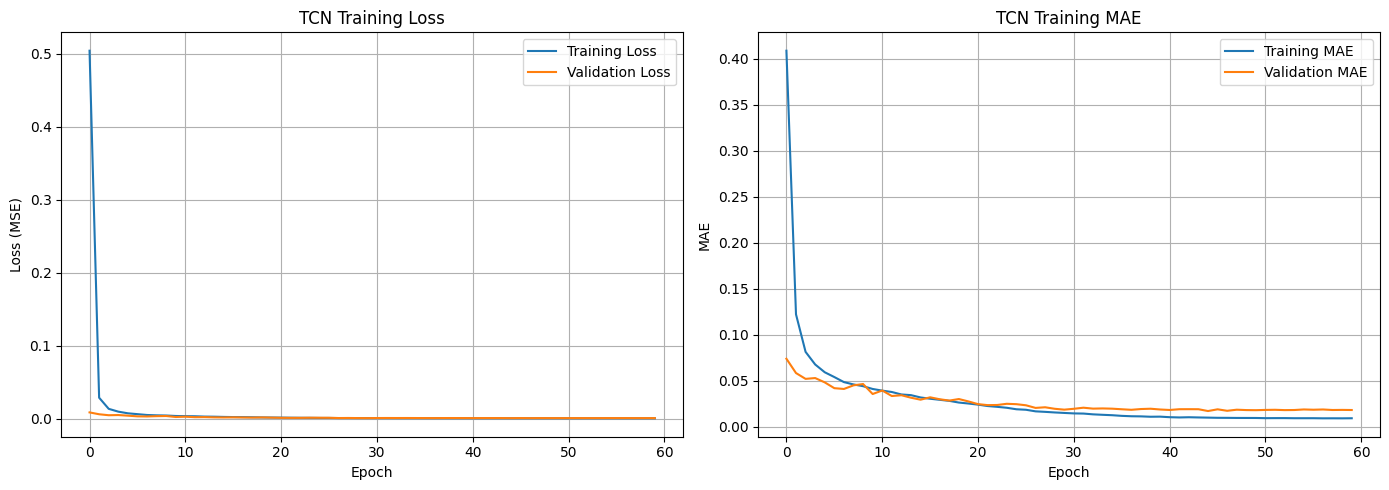

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('TCN Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True)

# MAE
axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title('TCN Training MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("images/tcn-training-history.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

In [27]:
# Save training history
history_df = pd.DataFrame(history.history)
history_df.to_csv('training_history_tcn.csv', index=False)
print('Training history saved to training_history_tcn.csv')

Training history saved to training_history_tcn.csv


## Predict Dataset

In [29]:
# Load best model with unsafe deserialization for Lambda layer
keras.config.enable_unsafe_deserialization()
model = keras.models.load_model(
    'models/tcn_k8s_best.keras',
    custom_objects={
        'CausalConv1D': CausalConv1D,
        'TemporalBlock': TemporalBlock,
        'TCN': TCN
    }
)
print('Loaded best model from checkpoint')

Loaded best model from checkpoint


In [30]:
pods_train_predict = model.predict(X_train_pods, verbose=0)

start_time = time.time()
pods_test_predict = model.predict(X_test_pods, verbose=0)
end_time = time.time()

prediction_time = (end_time - start_time) * 1000

print(f'POD DATASET - Prediction Size Train: {len(pods_train_predict)} | Prediction Size Test: {len(pods_test_predict)}')
print(f'Prediction Time: {prediction_time:.2f}ms')

POD DATASET - Prediction Size Train: 30203 | Prediction Size Test: 12945
Prediction Time: 2186.82ms


## Evaluate Model (Scaled Values)

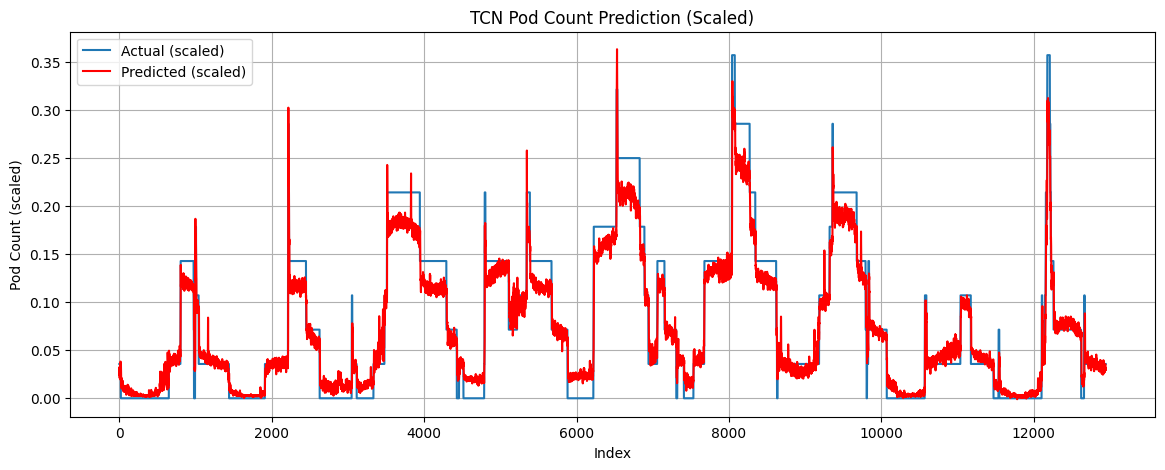

In [31]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_pods, label='Actual (scaled)', color='#1f77b4')
plt.plot(pods_test_predict, label='Predicted (scaled)', color='red')
plt.xlabel('Index')
plt.ylabel('Pod Count (scaled)')
plt.title('TCN Pod Count Prediction (Scaled)')
plt.legend() 
plt.grid(True)
plt.savefig("images/tcn-pods-scaled-output.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

In [32]:
mse_scaled = mean_squared_error(y_test_pods, pods_test_predict)
rmse_scaled = np.sqrt(mse_scaled)
mae_scaled = mean_absolute_error(y_test_pods, pods_test_predict)
r2_scaled = r2_score(y_test_pods, pods_test_predict)

print('=== TCN Model Metrics (Scaled Values) ===')
print(f'MSE: {mse_scaled:.6f}')
print(f'RMSE: {rmse_scaled:.6f}')
print(f'MAE: {mae_scaled:.6f}')
print(f'R²: {r2_scaled:.6f}')

=== TCN Model Metrics (Scaled Values) ===
MSE: 0.000433
RMSE: 0.020816
MAE: 0.015111
R²: 0.932690


## Inverse Transform & Final Evaluation

In [33]:
# Inverse transform predictions to original scale
y_test_actual = target_scaler.inverse_transform(y_test_pods.reshape(-1, 1)).flatten()
y_test_predicted = target_scaler.inverse_transform(pods_test_predict).flatten()

# Round to nearest integer (pod count should be whole numbers)
y_test_predicted_rounded = np.round(y_test_predicted).astype(int)
y_test_predicted_rounded = np.maximum(y_test_predicted_rounded, 1)  # Minimum 1 pod

print(f'Actual pods range: {y_test_actual.min():.0f} - {y_test_actual.max():.0f}')
print(f'Predicted pods range: {y_test_predicted_rounded.min()} - {y_test_predicted_rounded.max()}')

Actual pods range: 2 - 12
Predicted pods range: 2 - 12


In [ ]:
mse = mean_squared_error(y_test_actual, y_test_predicted_rounded)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, y_test_predicted_rounded)
r2 = r2_score(y_test_actual, y_test_predicted_rounded)

print('=== TCN Model Metrics (Pod Count) ===')
print(f'MSE: {mse:.6f}')
print(f'RMSE: {rmse:.6f}')
print(f'MAE: {mae:.6f}')
print(f'R²: {r2:.6f}')
print(f'Prediction Time: {prediction_time:.2f}ms')

=== TCN Model Metrics (Pod Count) ===
MSE: 0.421975
RMSE: 0.649596
MAE: 0.365763
R²: 0.916362
Prediction Time: 2006.65ms


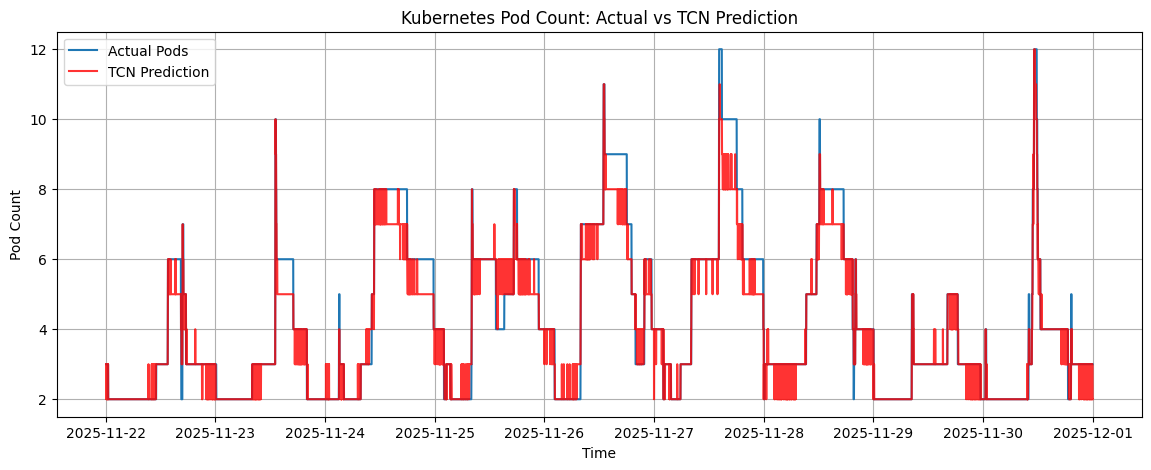

In [ ]:
# Get corresponding timestamps for test set
test_timestamps = df_pods['ds'].iloc[len(X_train_pods) + look_back:len(X_train_pods) + look_back + len(y_test_pods)].values

plt.figure(figsize=(14, 5))
plt.plot(test_timestamps, y_test_actual, label='Actual Pods', color='#1f77b4', linewidth=1.5)
plt.plot(test_timestamps, y_test_predicted_rounded, label='TCN Prediction', color='red', linewidth=1.5, alpha=0.8)
plt.title('Kubernetes Pod Count: Actual vs TCN Prediction')
plt.xlabel('Time')
plt.ylabel('Pod Count')
plt.grid(True)
plt.legend()
plt.savefig("images/tcn-pods-final-output.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

### Zoomed View (First 1000 samples)

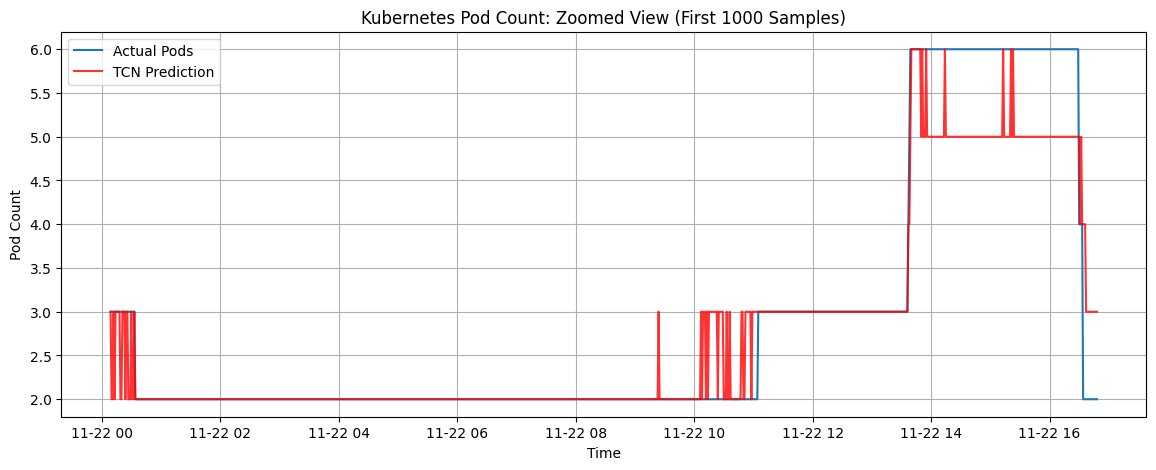

In [ ]:
zoom_samples = 1000

plt.figure(figsize=(14, 5))
plt.plot(test_timestamps[:zoom_samples], y_test_actual[:zoom_samples], label='Actual Pods', color='#1f77b4', linewidth=1.5)
plt.plot(test_timestamps[:zoom_samples], y_test_predicted_rounded[:zoom_samples], label='TCN Prediction', color='red', linewidth=1.5, alpha=0.8)
plt.title('Kubernetes Pod Count: Zoomed View (First 1000 Samples)')
plt.xlabel('Time')
plt.ylabel('Pod Count')
plt.grid(True)
plt.legend()
plt.savefig("images/tcn-pods-zoomed.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

## Error Analysis

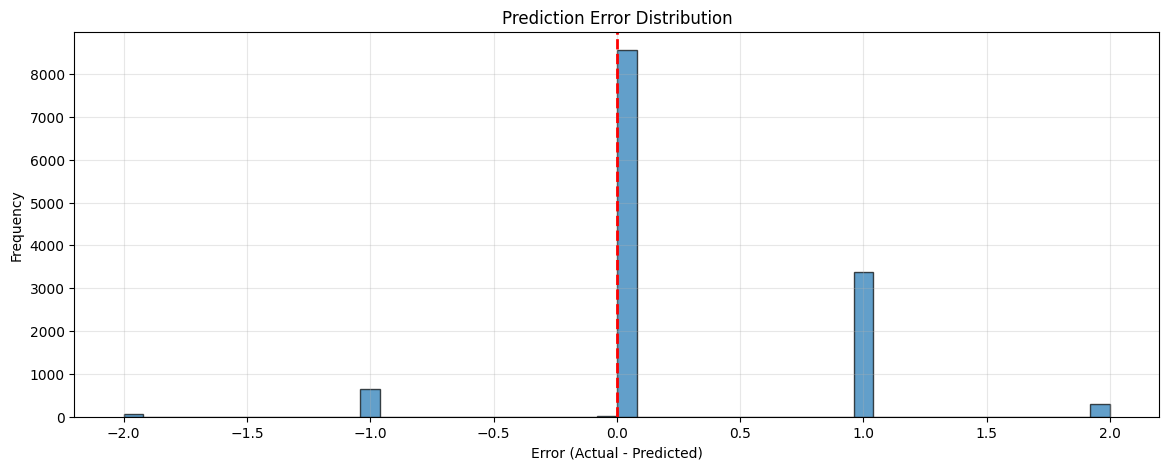

Mean Error: 0.2442
Std Error: 0.6019
Max Over-prediction: -2.0
Max Under-prediction: 2.0


In [ ]:
errors = y_test_actual - y_test_predicted_rounded

plt.figure(figsize=(14, 5))
plt.hist(errors, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.title('Prediction Error Distribution')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.savefig("images/tcn-error-distribution.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

print(f'Mean Error: {errors.mean():.4f}')
print(f'Std Error: {errors.std():.4f}')
print(f'Max Over-prediction: {errors.min()}')
print(f'Max Under-prediction: {errors.max()}')

In [ ]:
# Under-provisioning and Over-provisioning analysis
under_provisioned = (y_test_predicted_rounded < y_test_actual).sum()
over_provisioned = (y_test_predicted_rounded > y_test_actual).sum()
exact_match = (y_test_predicted_rounded == y_test_actual).sum()

total = len(y_test_actual)

print('=== Provisioning Analysis ===')
print(f'Under-provisioned: {under_provisioned} ({100*under_provisioned/total:.2f}%)')
print(f'Over-provisioned: {over_provisioned} ({100*over_provisioned/total:.2f}%)')
print(f'Exact match: {exact_match} ({100*exact_match/total:.2f}%)')

=== Provisioning Analysis ===
Under-provisioned: 3661 (28.27%)
Over-provisioned: 730 (5.64%)
Exact match: 8560 (66.10%)


## Save Model

In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save model
model_filename = f'models/tcn-pods-{timestamp}.keras'
model.save(model_filename)
print(f'Model saved: {model_filename}')

# Save scalers
import joblib
scaler_filename = f'models/tcn-scalers-{timestamp}.pkl'
joblib.dump({'target_scaler': target_scaler, 'feature_scaler': feature_scaler}, scaler_filename)
print(f'Scalers saved: {scaler_filename}')

Model saved: models/tcn-pods-20260101_213853.keras
Scalers saved: models/tcn-scalers-20260101_213853.pkl


## Summary

In [ ]:
print('=' * 60)
print('TCN MODEL SUMMARY')
print('=' * 60)
print(f'Dataset: data.csv ({primary_service})')
print(f'Total samples: {len(df_pods)}')
print(f'Features: {num_features} (multivariate + time features)')
print(f'Look-back window: {look_back}')
print(f'Train/Test split: 70/30')
print('-' * 60)
print('MODEL CONFIGURATION')
print('-' * 60)
print(f'num_channels: {NUM_CHANNELS}')
print(f'kernel_size: {KERNEL_SIZE}')
print(f'dropout_rate: {DROPOUT_RATE}')
print(f'receptive_field: {receptive_field} time steps')
print('-' * 60)
print('METRICS (Pod Count)')
print('-' * 60)
print(f'MSE: {mse:.6f}')
print(f'RMSE: {rmse:.6f}')
print(f'MAE: {mae:.6f}')
print(f'R²: {r2:.6f}')
print('-' * 60)
print('PROVISIONING')
print('-' * 60)
print(f'Under-provisioned: {100*under_provisioned/total:.2f}%')
print(f'Over-provisioned: {100*over_provisioned/total:.2f}%')
print(f'Exact match: {100*exact_match/total:.2f}%')
print('-' * 60)
print(f'Prediction Time: {prediction_time:.2f}ms')
print('=' * 60)

TCN MODEL SUMMARY
Dataset: data.csv (Order)
Total samples: 43200
Features: 25 (multivariate + time features)
Look-back window: 48
Train/Test split: 70/30
------------------------------------------------------------
MODEL CONFIGURATION
------------------------------------------------------------
num_channels: [64, 64, 64, 64]
kernel_size: 3
dropout_rate: 0.2
receptive_field: 61 time steps
------------------------------------------------------------
METRICS (Pod Count)
------------------------------------------------------------
MSE: 0.412746
RMSE: 0.642453
MAE: 0.361143
R²: 0.918218
------------------------------------------------------------
PROVISIONING
------------------------------------------------------------
Under-provisioned: 24.21%
Over-provisioned: 9.75%
Exact match: 66.04%
------------------------------------------------------------
Prediction Time: 2186.82ms


: 

## Model Comparison Notes

### TCN vs LSTM/Bi-LSTM vs Informer

| Aspect | TCN | LSTM/Bi-LSTM | Informer |
|--------|-----|--------------|----------|
| Architecture | Dilated Causal Conv | RNN-based | Transformer-based |
| Parallelization | Fully parallel | Sequential | Fully parallel |
| Receptive field | Exponential growth | Limited by hidden state | Full sequence |
| Training speed | Fast | Slow | Medium |
| Memory usage | Low | Medium | High |
| Long-range deps | Good (dilated conv) | Gradient issues | Excellent (attention) |
| Interpretability | Filter visualization | Hidden state | Attention weights |